In [2]:
import pandas as pd
import geopandas as gpd
import fiona
import numpy as np
import requests

In [2]:
calfire = gpd.read_file('California_Fire_Perimeters_(all).shp')

/opt/miniconda3/envs/burnseverity/lib/python3.13/site-packages/pyogrio/raw.py:198: RuntimeWarning: California_Fire_Perimeters_(all).shp contains polygon(s) with rings with invalid winding order. Autocorrecting them, but that shapefile should be corrected using ogr2ogr for example.
  return ogr_read(


In [3]:
calfire_filtered = calfire[(calfire['YEAR_'] > 2015) & (calfire['AGENCY'] == 'NPS')].copy()
unique_parks = calfire_filtered['UNIT_ID'].unique()

UNIT_ID
KNP    20
MNP    12
SMP     7
JTP     2
CNP     2
Name: count, dtype: int64


/opt/miniconda3/envs/burnseverity/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field ALARM_DATE created as String field, though DateTime requested.
  ogr_write(
/opt/miniconda3/envs/burnseverity/lib/python3.13/site-packages/pyogrio/raw.py:723: RuntimeWarning: Field CONT_DATE created as String field, though DateTime requested.
  ogr_write(


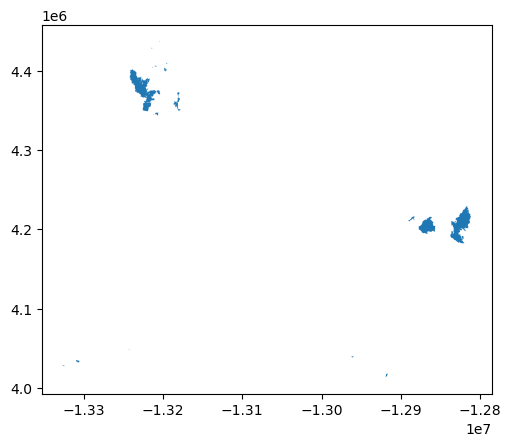

In [4]:
parks = ['JTP', 'MNP', 'KNP', 'CNP', 'SMP']
calfire_filtered_parks = calfire_filtered[(calfire_filtered['UNIT_ID'].isin(parks))].copy()
print(calfire_filtered_parks['UNIT_ID'].value_counts())
calfire_filtered_parks.plot()
calfire_filtered_parks.to_file('Validation_Fire_Perimeters_2015_2024.shp')

In [57]:
import pandas as pd
df_results = pd.DataFrame(results)
df_results.to_csv('fire_processing_jobs.csv', index=False)

print(f"\nProcessed {len(results)} requests. Results saved to fire_processing_jobs.csv")
display(df_results)



Processed 328 requests. Results saved to fire_processing_jobs.csv


,fire_event_name,job_id,fire_name,post_fire_days,status
0,COFFEE POT_2024-08-03_5,573421be-412c-403d-9d72-b591de886c43,COFFEE POT,5,success
1,COFFEE POT_2024-08-03_10,eb5075d7-06b1-401d-9aa5-ba94efebc8e0,COFFEE POT,10,success
2,COFFEE POT_2024-08-03_15,743d5692-aafc-4230-9e57-f9db89bade40,COFFEE POT,15,success
3,COFFEE POT_2024-08-03_21,83abcfa3-75c4-4350-855d-12c4af526810,COFFEE POT,21,success
4,COFFEE POT_2024-08-03_30,a269a19f-a8ee-49e7-80d9-836497cf96fe,COFFEE POT,30,success
...,...,...,...,...,...
323,LIBERTY CANYON_2016-11-05_21,bc3d5e99-a7e4-4488-a092-04a0df1fc0b2,LIBERTY CANYON,21,success
324,LIBERTY CANYON_2016-11-05_30,49f3b8c1-c577-44a2-bdfc-740b1317a557,LIBERTY CANYON,30,success
325,LIBERTY CANYON_2016-11-05_45,cac865be-7853-4609-a9e3-ff4904a8888c,LIBERTY CANYON,45,success
326,LIBERTY CANYON_2016-11-05_60,f92febfb-6aa7-4aaa-a283-33d25ec3e39f,LIBERTY CANYON,60,success
